# Basic analysis example: accessibility in Valparaíso, Chile

This notebook contains a basic example for the kinds of analyses that can be produced using the `xmin` library.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import datetime
from pathlib import Path

In [3]:
import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import TwoStepFca

In [49]:
RAW_DATA_PATH = Path("../../data/raw")  # non-processed data
PRE_DATA_PATH = Path("../../data/processed")  # pre-processed data
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

## Data sources

To download and clean the data used in this example, you must execute one of
the following commands:

```
$ make dataset_all
$ uv run scripts/make_dataset.py all
```

Specific data sources used in this example:
- [2024 Chilean census](https://censo2024.ine.gob.cl/resultados/)
- [OSM dataset for Chile](https://download.geofabrik.de/south-america/chile.html)
- [Quality indicators for urban green spaces in Chile (2019)](https://arcg.is/1LTLCf)
- [Health facilities in Chile (December 2025)](https://geoportal.cl/geoportal/catalog/36779/Establecimientos%20de%20salud%20de%20Chile%20Diciembre%202025)

In [8]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSUS_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_GREEN_PATH = PRE_DATA_PATH / "amenities" / "areas_verdes.gpkg"
AMENITY_HEALTH_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
OSM_VALPARAISO_PATH = PRE_DATA_PATH / "osm" / "Valparaiso.osm.pbf"

## Límites urbanos y orígenes

In [9]:
urban_boundaries_full = gpd.read_file(
    CENSUS_PATH,
    layer="Limite_Urbano_CPV24",
)

# we only filter boundaries corresponding to Valparaíso
urban_boundaries = urban_boundaries_full[
    (urban_boundaries_full["LOCALIDAD"] == "GRAN VALPARAÍSO")
]

# we get the convex hull to extract POIs and road network
boundaries_hull = urban_boundaries.union_all().convex_hull

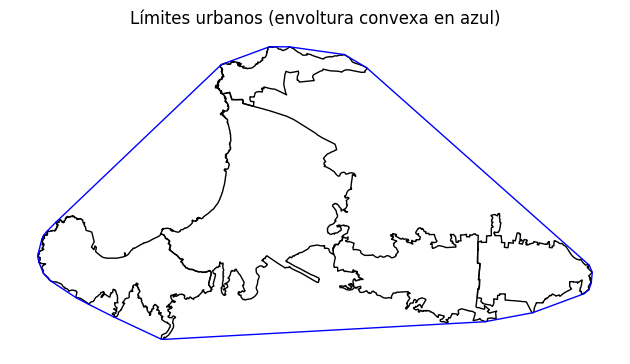

In [ ]:
ax = urban_boundaries.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([boundaries_hull]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
ax.set_axis_off()
plt.title("Urban boundaries (convex hull in blue)")
plt.tight_layout()

In [10]:
city_blocks = gpd.read_file(
    CENSUS_PATH,
    layer="Manzanas_CPV24",
    mask=urban_boundaries.union_all(),
    use_arrow=True
).rename(columns={"n_per": "population"})

Firstly, we create the origin grid for which accessibility indices will be
calculated. Each cell is assigned a population taken from the city squares
which intersect it.

In [12]:
origins = xmin.Origins.create_grid(
    regions=urban_boundaries,
    h3_resolution=9,
    population_gdf=city_blocks
)
len(origins.h3_grid)

1796

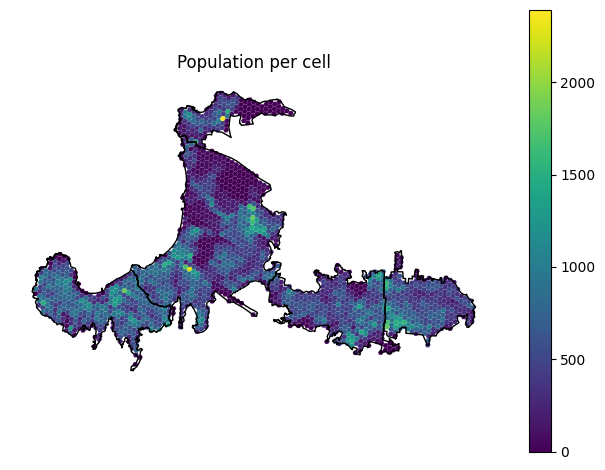

In [13]:
ax = origins.h3_grid.plot("population", legend=True)
urban_boundaries.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title("Population per cell")
plt.tight_layout()

## OSM and amenities

The second step is to create the destinations; these are grouped according to
the necessity they satisfy (one `Amenity` object for each necessity or
category). Destinations can be loaded from OSM as well as manually through
existing GeoDataFrames.

In [14]:
if not OSM_VALPARAISO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_VALPARAISO_PATH,
        bounds=boundaries_hull
    )

In [17]:
# POIs can be loaded from OSM via a PBF file cropped to the region of interest
pharmacies = xmin.Amenity.from_osm(
    name="pharmacies",
    osm_path=OSM_VALPARAISO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
)

In [18]:
# or they can be loaded from a non-cropped PBF file, providing the boundaries
# (this takes a bit longer)
supermarkets = xmin.Amenity.from_osm(
    name="supermarkets",
    osm_path=OSM_CHILE_PATH,
    osm_filter={"shop": ["supermarket"]},
    bounds=boundaries_hull,
)

In [19]:
green_gdf = gpd.read_file(AMENITY_GREEN_PATH, layer="puntos")

# you can manually filter points from a geodataframe given a boundary
green_gdf = green_gdf[green_gdf.within(boundaries_hull)]

In [20]:
plazas = xmin.Amenity("plazas", green_gdf[green_gdf["TIPO_EP"]=="PLAZA"])
parks = xmin.Amenity("parks", green_gdf[green_gdf["TIPO_EP"]=="PARQUE"])

In [21]:
health_gdf = gpd.read_file(AMENITY_HEALTH_PATH)

In [30]:
# you can filter with a polygon while creating the Amenity object
salud = xmin.Amenity(
    "health",
    health_gdf[health_gdf["NIVEL"]=="Primario"],
    bounds=boundaries_hull
)

## Travel time and accessibility index calculation

Once you have origins and destinations, you can calculate the travel time
matrix for each amenity.

In [31]:
ttms = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[pharmacies, supermarkets, salud, plazas, parks],
    gtfs_paths=[],
    osm_path=OSM_VALPARAISO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
    chunk_size=50
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/1796 [00:00<?, ?it/s]

In [32]:
ttm_pharmacies = ttms.matrices["pharmacies"]
ttm_pharmacies[ttm_pharmacies["travel_time"].notna()].sample(10)

,from_id,to_id,travel_time
4744,89b2c40803bffff,pharmacies/node/3600684837,16.0
26166,89b2c40f653ffff,pharmacies/node/9401102453,10.0
4217,89b2c40e07bffff,pharmacies/node/7289335937,19.0
63165,89b2c4199afffff,pharmacies/node/12154445752,6.0
31671,89b2c408233ffff,pharmacies/node/4944967572,29.0
9561,89b2c4092b7ffff,pharmacies/node/3616453128,15.0
43619,89b2c4080cfffff,pharmacies/node/9945572435,10.0
38343,89b2c418a3bffff,pharmacies/node/12124802412,10.0
35048,89b2c4093afffff,pharmacies/node/3393341425,15.0
33644,89b2c4092afffff,pharmacies/node/3393341966,17.0


Finally, a score is calculated for each amenity (using some index function),
and these scores are weighted to obtain a "total" accessibility score.

In [33]:
weights = {
    pharmacies: 1,
    supermarkets: 1,
    plazas: 0.5,
    parks: 0.5,
    salud: 1
}

indices = {
    pharmacies: TwoStepFca(15, 3_000),
    supermarkets: TwoStepFca(15, 3_000),
    salud: TwoStepFca(30, 10_000),
    # each green space has a weight propotional to its area, so the ratio here
    # is not people per green space, but people per square meter of green space
    plazas: TwoStepFca(10, 1),
    parks: TwoStepFca(20, 1),
}

In [34]:
acc = xmin.AccessibilityRatings.compute(
    ttms,
    indices,
    weights
)

Calculando índices para cada necesidad...


  0%|          | 0/5 [00:00<?, ?it/s]

## Visualizaciones

Using the `AccessibilityRatings` object, you can obtain different types of visualizations. All visualizations can be generated statically (a `matplotlib` figure) or interactively (a `folium` map). Also, for each visualization, these optional overlays can be added:

- The boundaries of the regions considered in the analysis (shown by default).
- A base map (not shown by default).
- A scale bar (not shown by default).
- The main roads of the region (not shown by default).
- Destinations considered in the analysis (not shown by default).

The simplest visualization is a choropleth map showing the total (combined)
accessibility rating (or score) for each origin. Here, roads and a scale bar
are also added to the figure.

Output()

Finished operation in 0:00:08

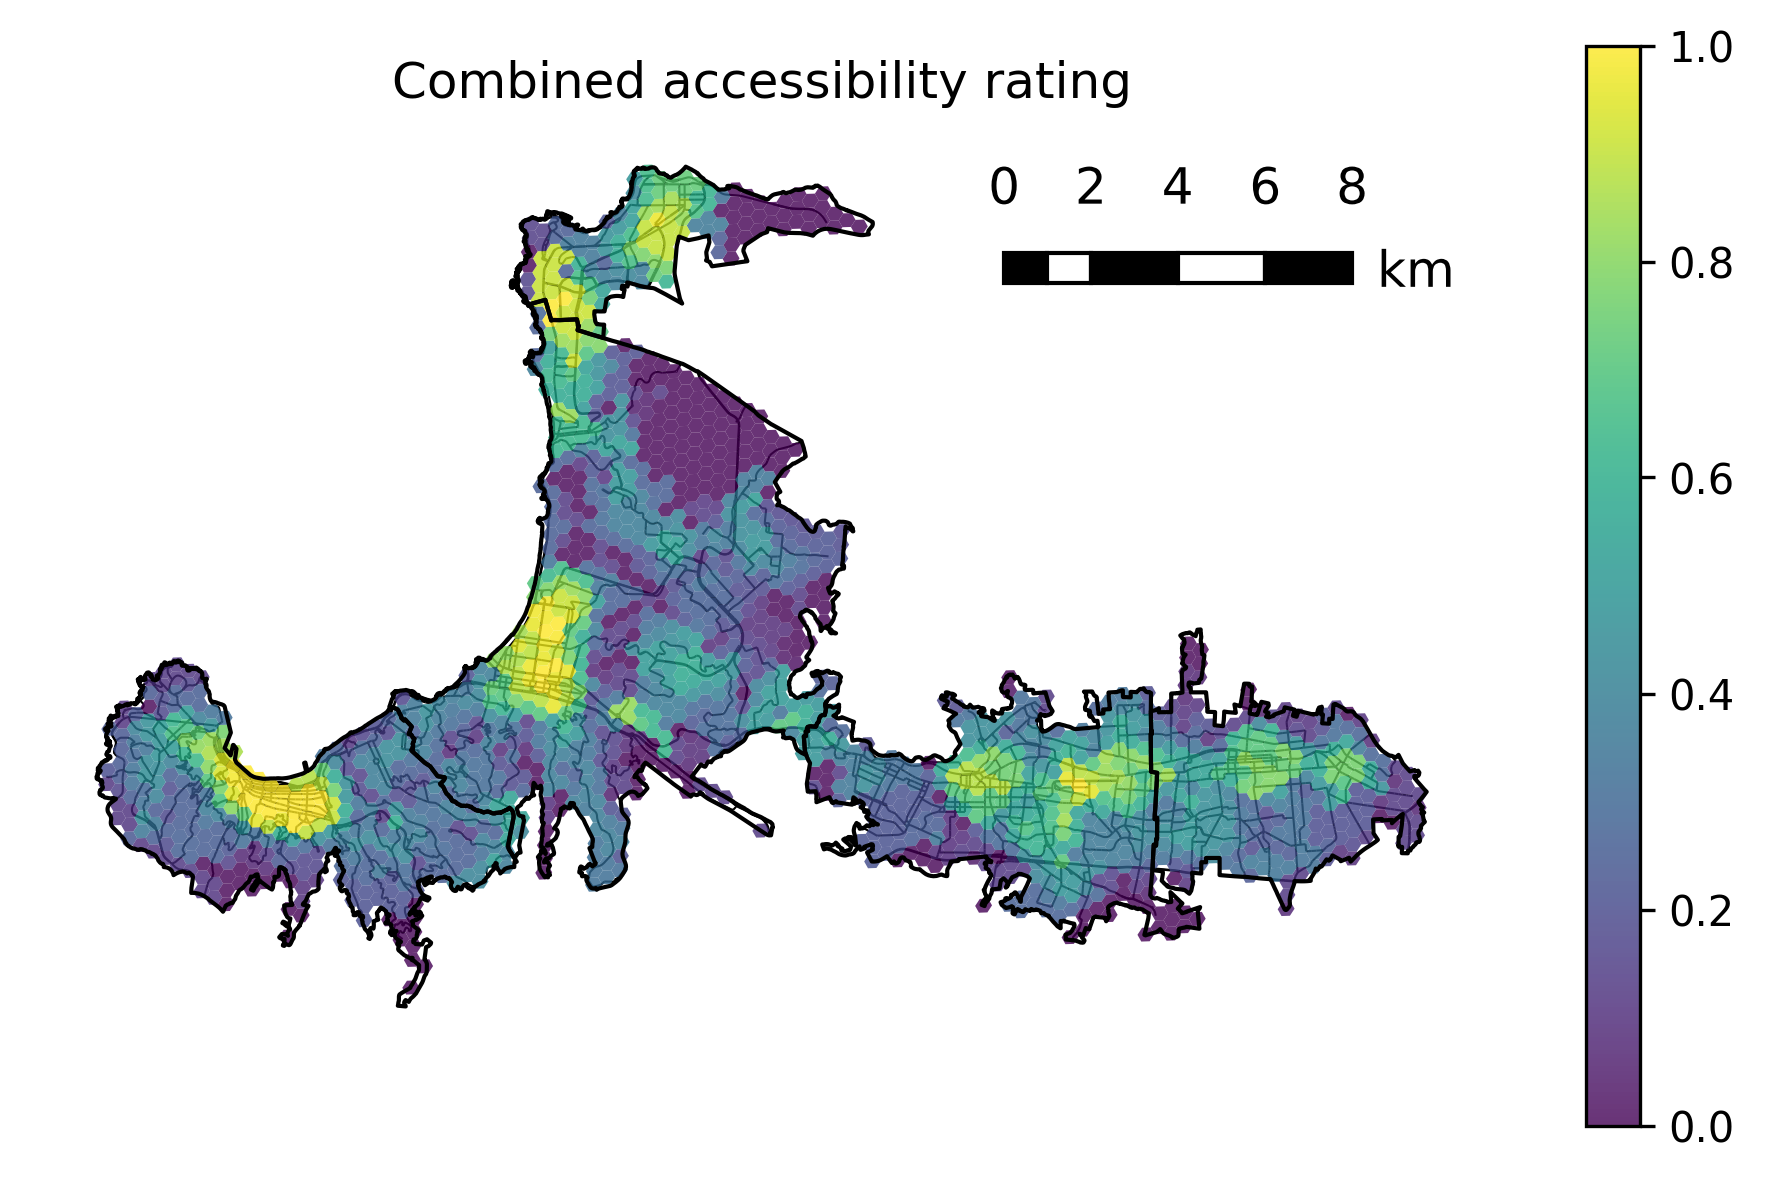

In [27]:
fig, ax = plt.subplots(dpi=300)
acc.visualize.choropleth(
    "total",
    interactive=False,
    legend=True,
    overlay_cfg=xmin.OverlayConfig(
        show_scalebar=True,
        show_roads=True,
        roads_pbf_path=OSM_VALPARAISO_PATH,
    ),
    legend_kwds={
        "alpha": xmin.config.alpha_when_background,
        "shrink": 0.8
    },
    ax=ax
)
ax.set_axis_off()
plt.title("Combined accessibility rating")
plt.tight_layout()

This same figure can be displayed interactively, and now also showing the
position of the different destinations considered in the analysis.

If the map in the cell below does not load, adding an empty Markdown cell below
the cell containing the map seems to solve the problem.

In [35]:
acc.visualize.choropleth(
    "total",
    interactive=True,
    legend=True,
    scheme="EqualInterval",
    overlay_cfg=xmin.OverlayConfig(show_amenities=True),
)

Each call to a method from `AccessibilityRatings.visualize` returns a
`matplotlib` axis (if `interactive=False`), so they can be combined or modified
as desired. Here we combine four choropleth maps showing scores for four
different amenity types.

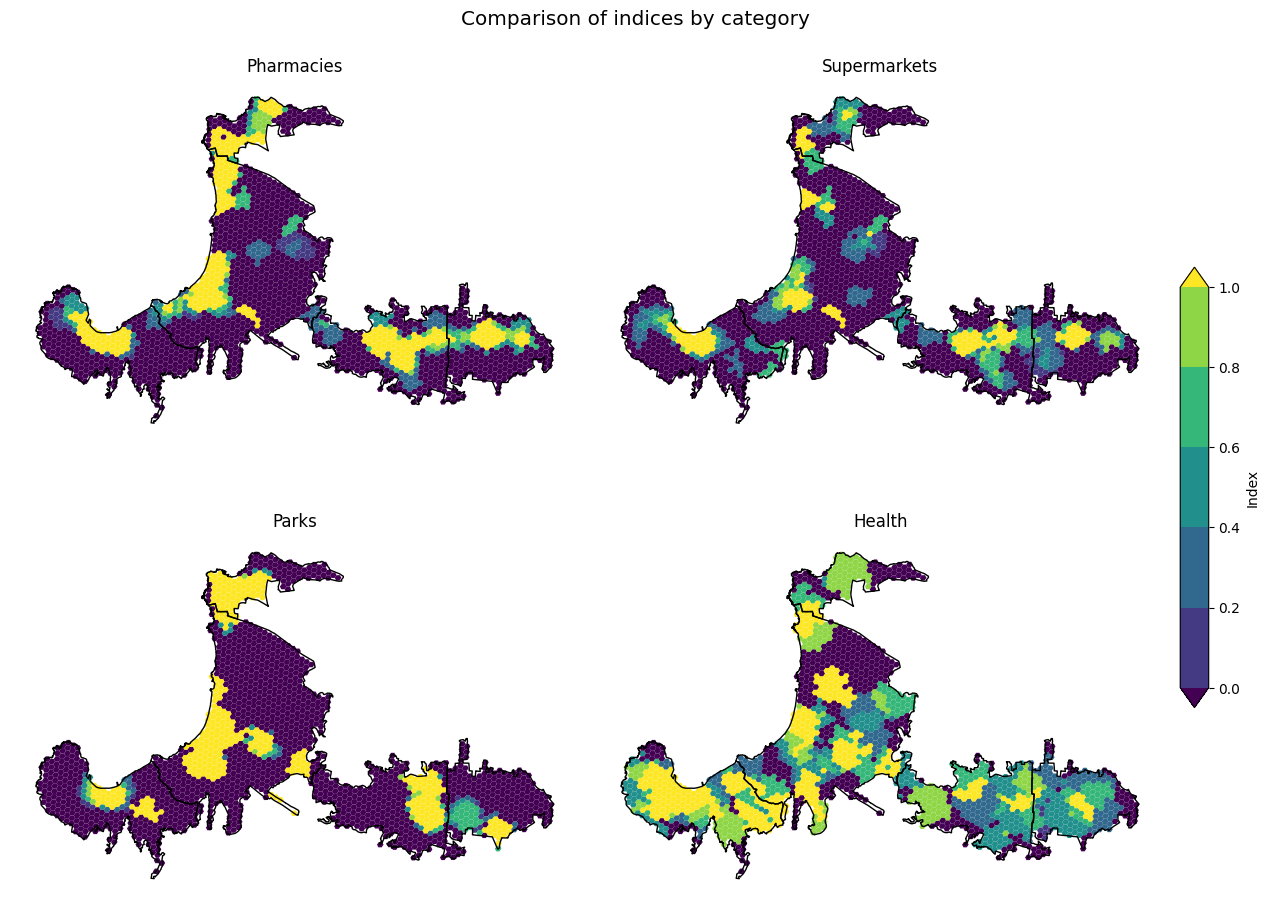

In [38]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_pharmacies = fig.add_subplot(gs[0:2, 0])
ax_supermarkets = fig.add_subplot(gs[0:2, 1])
ax_parks = fig.add_subplot(gs[2:4, 0])
ax_health = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

norm = mcolors.BoundaryNorm(
    [1e-10, 0.2, 0.4, 0.6, 0.8, 1.0], ncolors=256, extend="both"
)

for ax, category in zip(
    (ax_pharmacies, ax_supermarkets, ax_parks, ax_health),
    ("pharmacies", "supermarkets", "parks", "health"),
):

    acc.visualize.choropleth(category, ax=ax, norm=norm)
    ax.set_axis_off()
    ax.set_title(category.capitalize())

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Index")

fig.suptitle("Comparison of indices by category", fontsize="x-large")

plt.tight_layout()

Other visualizations are also possible. Here we show NEXI-Discomfort, which
reveals that not all low accessibility zones have high discomfort, because many
of these zones are sparsely populated. We also add a base map to the
visualization.

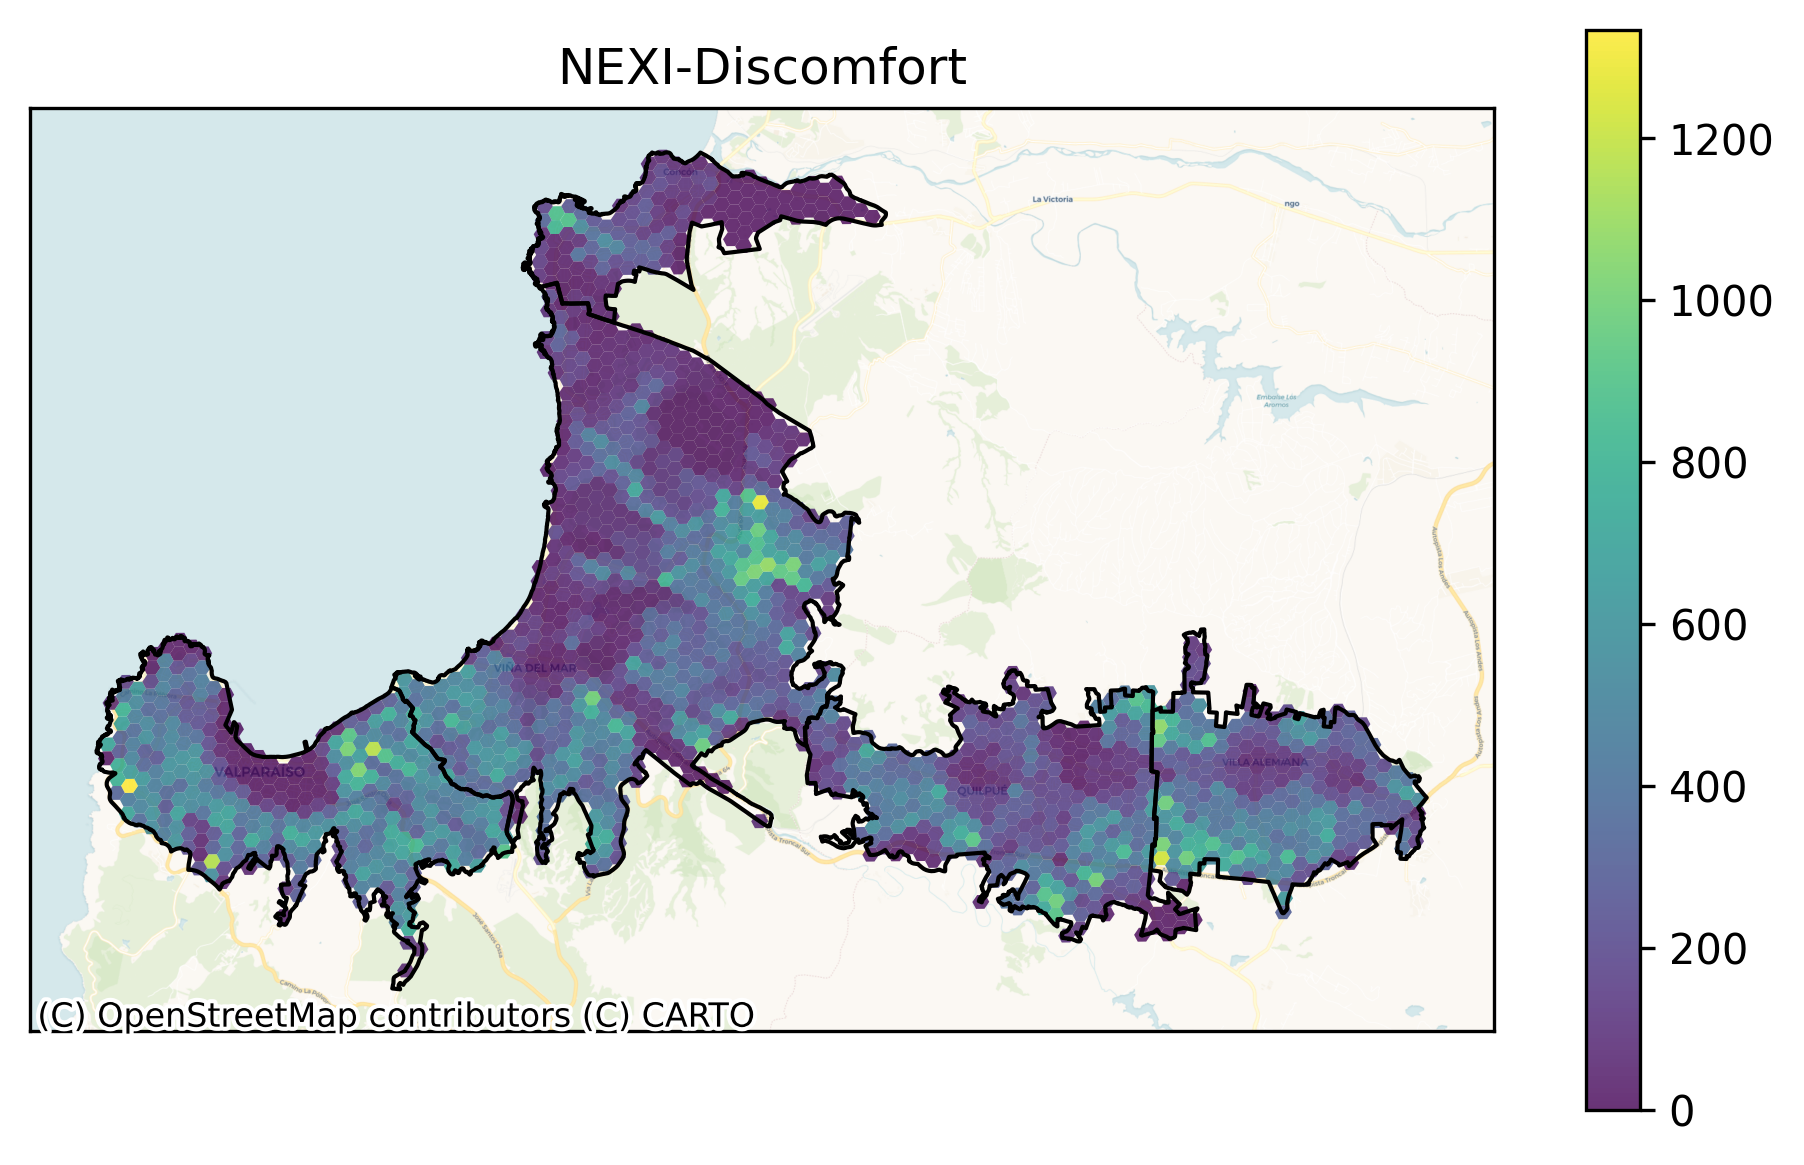

In [37]:
fig, ax = plt.subplots(dpi=300)
ax = acc.visualize.nexi_discomfort(
    "total",
    ax=ax,
    interactive=False,
    legend=True,
    legend_kwds={"alpha": xmin.config.alpha_when_background, "shrink": 0.8},
    overlay_cfg=xmin.OverlayConfig(show_basemap=True, basemap_kwds={"zoom": 13, "source": "CartoDB Voyager"})
)
ax.set_xticks([])
ax.set_yticks([])
plt.title("NEXI-Discomfort")
plt.tight_layout()

Two variables can be visualized at once. In this case, we are comparing
accessibility to parks (large green areas) and *plazas* (smaller green areas).

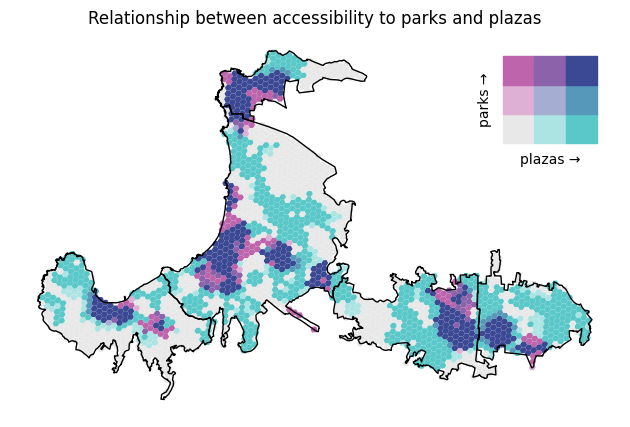

In [39]:
ax = acc.visualize.bivariate_choropleth(
    "parks", "plazas", legend_kwds={"bounds": [0.80, 0.70, 0.17, 0.25]}
)
ax.set_axis_off()
plt.title("Relationship between accessibility to parks and plazas")
plt.tight_layout()

We can also visualize the "most urgent" amenity category in each origin (the one that would increase the weighed rating the most, if the rating for the amenity category were to increase to 100%).

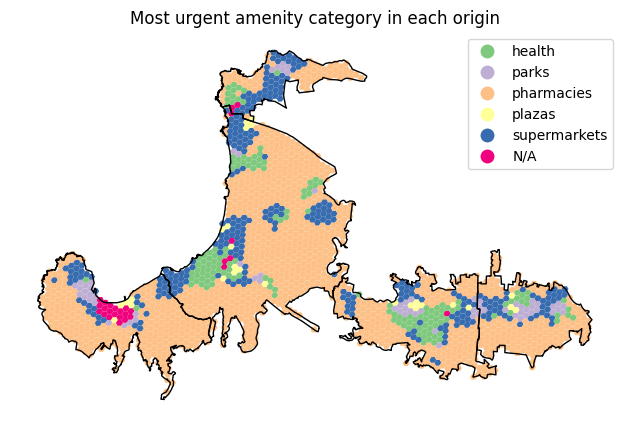

In [40]:
ax = acc.visualize.most_urgent_amenity(legend=True)
ax.set_axis_off()
plt.title("Most urgent amenity category in each origin")
plt.tight_layout()

Finally, we can visualize spatial association clusters using Local Moran's I.

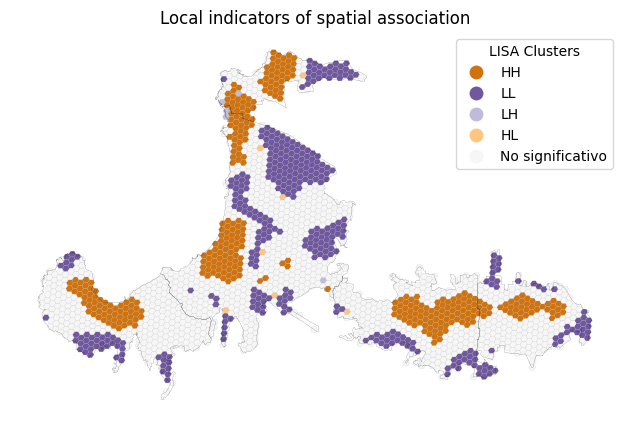

In [ ]:
ax = acc.visualize.lisa(
    legend=True,
    legend_kwds={"title": "LISA Clusters"},
    linewidth=0.1,
    edgecolor="#abacab",
    overlay_cfg=xmin.OverlayConfig(borders_kwds={"linewidth": 0.1}),
)
ax.set_axis_off()
plt.title("Local indicators of spatial association")
plt.tight_layout()

## Cropping and aggregation

Once the `AccessibilityRatings` object is generated, it can be modified to
include only certain areas, or to aggregate cells to a lower H3 resolution (and
thus reduce the dependence on the exact starting point selected for each
origin).

In [42]:
# we create new boundaries (just Valparaíso proper, divided into its census
# districts)
districts = gpd.read_file(
    CENSUS_PATH,
    layer="Distrital_CPV24",
)
new_regions = districts[districts["COMUNA"]=="VALPARAÍSO"]

In [43]:
# we get a warning because the new area is larger than the original one; only
# the intersection between both is considered
cropped_acc = acc.crop(new_regions)

/home/clau/x-minute-chile/xmin/ratings.py:232: UserWarning: Área nueva no está completamente contenida en el área original; solo se considerará la porción del área nueva que está contenida en el área original.
  warnings.warn(new_bounds_too_large_text)


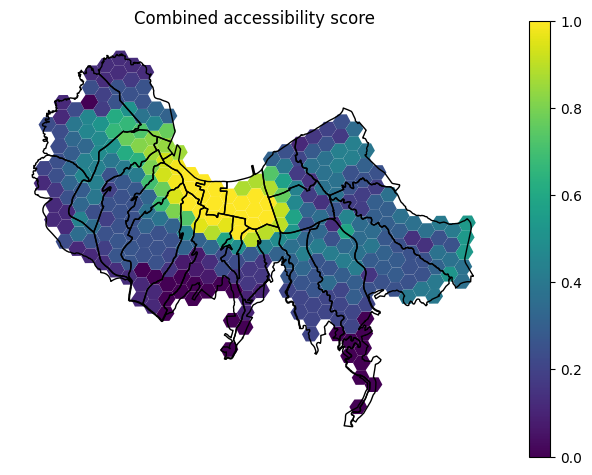

In [44]:
ax = cropped_acc.visualize.choropleth("total", legend=True)
ax.set_axis_off()
plt.title("Combined accessibility score")
plt.tight_layout()

In [45]:
# new boundaries (only a polygon, so we keep the old regions)
new_bounds = urban_boundaries_full[
    urban_boundaries_full["COMUNA"].isin(["QUILPUÉ", "VILLA ALEMANA"])
].union_all()
cropped_acc = acc.crop(new_bounds)

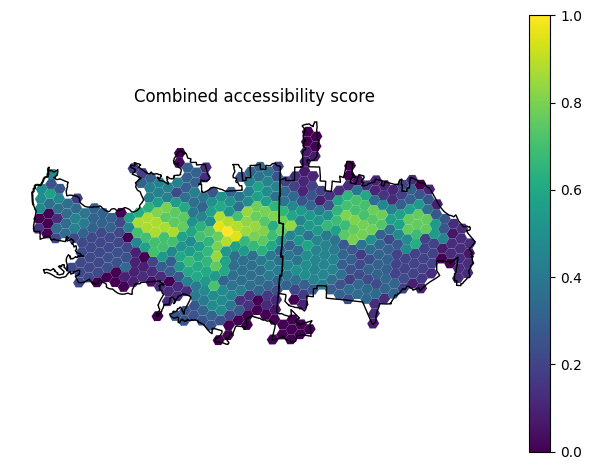

In [46]:
ax = cropped_acc.visualize.choropleth("total", legend=True)
ax.set_axis_off()
plt.title("Combined accessibility score")
plt.tight_layout()

In [47]:
# we reduce cell resolution, averaging the old scores within each new cell
agg_acc = acc.aggregate(8)

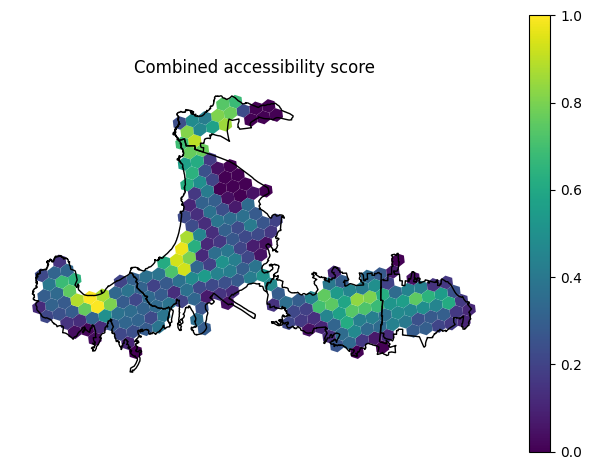

In [48]:
ax = agg_acc.visualize.choropleth("total", legend=True)
ax.set_axis_off()
plt.title("Combined accessibility score")
plt.tight_layout()